<a href="https://colab.research.google.com/github/lilianabs/hugging-face-review/blob/main/Text_classification_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load a dataset using Hugging Face

In [9]:
from huggingface_hub import HfApi

# Initialize the API client
api = HfApi()

# Fetch all datasets
datasets = api.list_datasets()

# Print the first 10 dataset IDs as an example
for i, dataset in enumerate(datasets):
    if i >= 10:
        break
    print(dataset.id)

HuggingFaceCode/stack-v3-train
SupraLabs/reasoning-corpus-4K-5M-v1
Manusagents/GPT-5.5-Gemini-3.1-Pro-Grok-4-Claude-Fable-5-Mythos-5-Qwen-3.7-Max-and-more-Distillation-Dataset
FlyRank/internship-warehouse
r0b0tlab/qwen3.8-max-distillation-50k
unstonio/pixelgpt-24x24-20k
Glint-Research/Fable-5-traces
greghavens/kimi-k3-coding-and-debugging-traces
moonshotai/PerceptionBench
ianncity/GLM-5.2-Conversation


In [12]:
from datasets import load_dataset
emotions = load_dataset('dair-ai/emotion')

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [13]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [14]:
train_ds = emotions['train']
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [16]:
# Access a single example by its index
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [17]:
print(train_ds.features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [18]:
import pandas as pd

In [19]:
emotions.set_format(type="pandas")

In [20]:
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [22]:
# Add full label names
def label_int2str(row):
  return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## EDA

In [23]:
import matplotlib.pyplot as plt


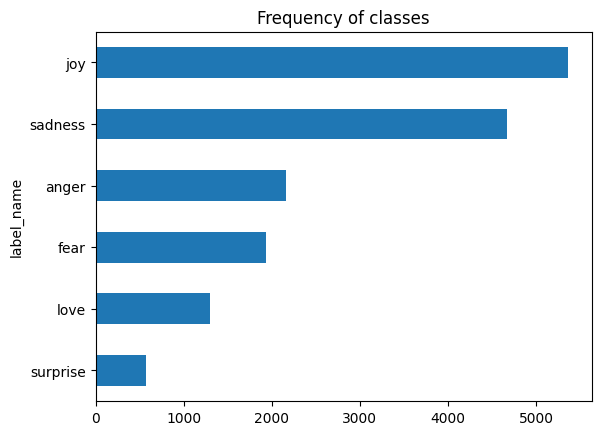

In [24]:
df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of classes")
plt.show()

Text(0.5, 0, '')

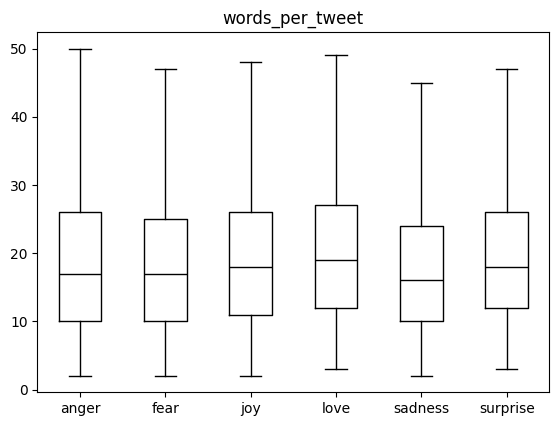

In [32]:
df["words_per_tweet"] = df["text"].str.split().apply(len)
df.boxplot("words_per_tweet", by="label_name",
           grid=False, color="black", showfliers=False);
plt.suptitle("")
plt.xlabel("")

In [28]:
df.head()

,text,label,label_name,words_per_tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4
